A Model that will be able to predict if a person has a heart disease based on their medical metrics

In [334]:
#Git Commands 

!git add . 
!git commit -m"Project heart disease analysis"
!git push -u origin main
!git status

[main 3fdd4d1] Project heart disease analysis
 1 file changed, 18 insertions(+), 24 deletions(-)
Enumerating objects: 9, done.
Counting objects: 100% (9/9), done.
Delta compression using up to 8 threads
Compressing objects: 100% (5/5), done.
Writing objects: 100% (5/5), 651 bytes | 651.00 KiB/s, done.
Total 5 (delta 3), reused 0 (delta 0), pack-reused 0 (from 0)
remote: Resolving deltas: 100% (3/3), completed with 3 local objects.
To https://github.com/NimbalkarYash/Machine_learning
   ad1462b..3fdd4d1  main -> main
branch 'main' set up to track 'origin/main'.
On branch main
Your branch is up to date with 'origin/main'.

Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	modified:   ../../.gitignore
	modified:   ../.DS_Store

no changes added to commit (use "git add" and/or "git commit -a")


In [287]:
#TOOLS THAT I HAVE USED ARE IMPORTED IN THIS CELL

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [288]:
#MACHINE LEARNING MODELS

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

#MODEL EVALUATIONS TOOLS

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.metrics import confusion_matrix 
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import RocCurveDisplay

In [289]:
#IMPORTING THE DATA WE ARE GOING TO WORK WITH

df = pd.read_csv("heart-disease.csv")
df.shape #(rows, cols)
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


<class 'pandas.Series'>
RangeIndex: 303 entries, 0 to 302
Series name: target
Non-Null Count  Dtype
--------------  -----
303 non-null    int64
dtypes: int64(1)
memory usage: 2.5 KB
None
__________________________TYPE OF VALUES__________________
target
1    165
0    138
Name: count, dtype: int64
__________________________NULL VALUES_____________________
0
__________________________DATA DESCRIPTION__________________
count    303.000000
mean       0.544554
std        0.498835
min        0.000000
25%        0.000000
50%        1.000000
75%        1.000000
max        1.000000
Name: target, dtype: float64


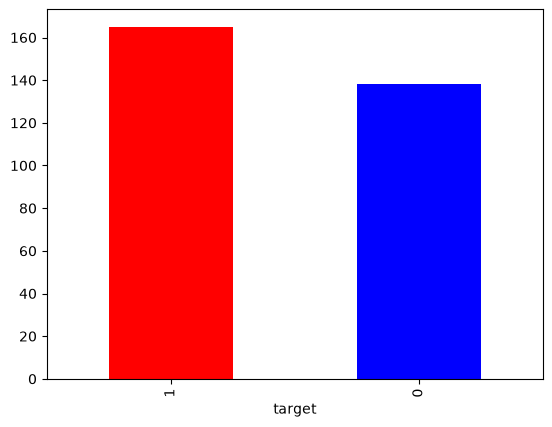

In [290]:
#DATA EXPLORATION

print(df["target"].info())
print("__________________________TYPE OF VALUES__________________")
print(df["target"].value_counts())
print("__________________________NULL VALUES_____________________")
print(df["target"].isnull().sum())

df["target"].value_counts().plot(kind = "bar",color= ['red', 'blue'] )
print("__________________________DATA DESCRIPTION__________________")
print(df["target"].describe())

(array([0, 1]), [Text(0, 0, '0'), Text(1, 0, '1')])

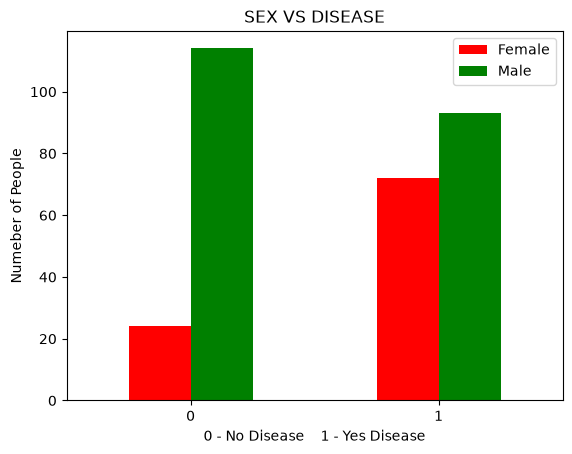

In [291]:
#FINDING PATTERS


#REALTIONSHIP BETWEEN GENDER AND OUTCOME
pd.crosstab(df['target'], df['sex'])


pd.crosstab(df['target'], df['sex']).plot(kind='bar', color =['red', 'green'])
plt.title("SEX VS DISEASE")
plt.xlabel("0 - No Disease    1 - Yes Disease" )
plt.ylabel("Numeber of People")
plt.legend(["Female", "Male"])
plt.xticks(rotation = 0)

Text(0.5, 1.0, 'COMPARISION BETWEEN AGE AND DISEASE')

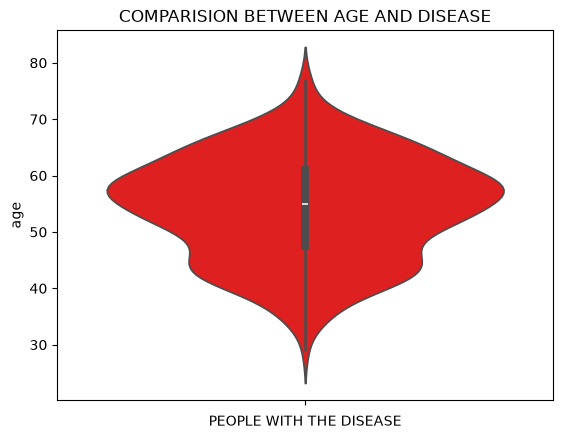

In [292]:
#COMPARISION BETWEEN AGE AND DISEASE

peopleWith = df[df['target'] == 1]
sns.violinplot(data = peopleWith, y = df['age'], color = 'red')
plt.xlabel("PEOPLE WITH THE DISEASE")
plt.title("COMPARISION BETWEEN AGE AND DISEASE")


<Axes: xlabel='age', ylabel='Count'>

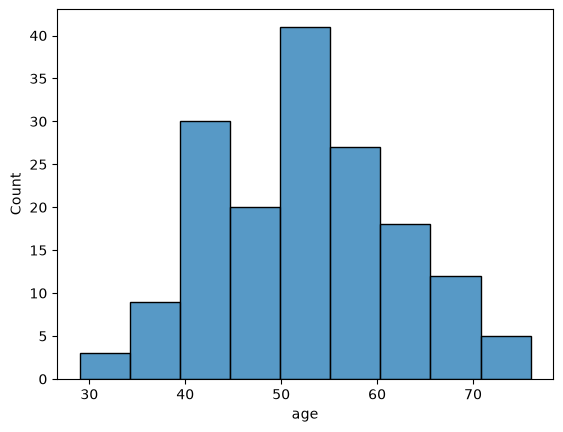

In [293]:
sns.histplot(data = peopleWith, x = peopleWith['age'])

<Axes: ylabel='Frequency'>

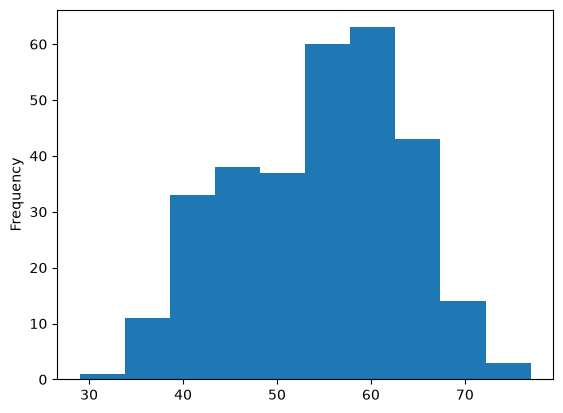

In [294]:
df.age.plot.hist()

<Axes: xlabel='target', ylabel='cp'>

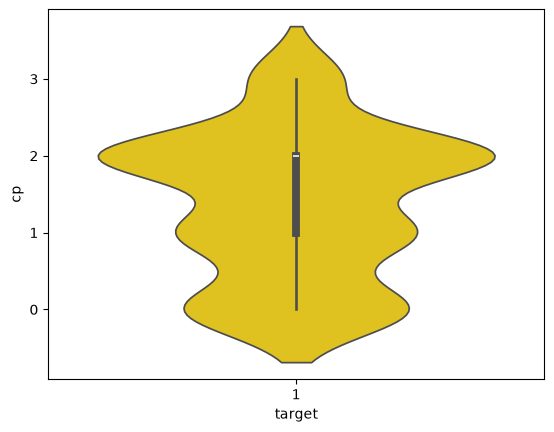

In [295]:
#Comparing hear disease with chest pain

pd.crosstab(df.target, df.cp)

sns.violinplot(data = peopleWith, x = 'target', y = 'cp', color = 'gold')

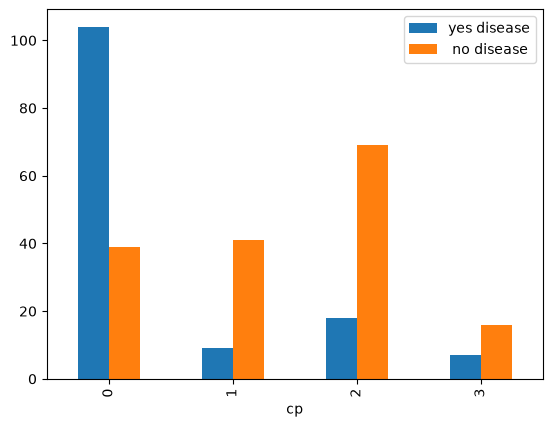

In [296]:
pd.crosstab(df.cp, df.target).plot(kind = 'bar')
plt.legend(['yes disease', ' no disease'])

In [297]:
corrMatrix = df.corr()
corrMatrix

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
age,1.000000,-0.098447,-0.068653,0.279351,0.213678,0.121308,-0.116211,-0.398522,0.096801,0.210013,-0.168814,0.276326,0.068001,-0.225439
sex,-0.098447,1.000000,-0.049353,-0.056769,-0.197912,0.045032,-0.058196,-0.044020,0.141664,0.096093,-0.030711,0.118261,0.210041,-0.280937
cp,-0.068653,-0.049353,1.000000,0.047608,-0.076904,0.094444,0.044421,0.295762,-0.394280,-0.149230,0.119717,-0.181053,-0.161736,0.433798
trestbps,0.279351,-0.056769,0.047608,1.000000,0.123174,0.177531,-0.114103,-0.046698,0.067616,0.193216,-0.121475,0.101389,0.062210,-0.144931
chol,0.213678,-0.197912,-0.076904,0.123174,1.000000,0.013294,-0.151040,-0.009940,0.067023,0.053952,-0.004038,0.070511,0.098803,-0.085239
fbs,0.121308,0.045032,0.094444,0.177531,0.013294,1.000000,-0.084189,-0.008567,0.025665,0.005747,-0.059894,0.137979,-0.032019,-0.028046
restecg,-0.116211,-0.058196,0.044421,-0.114103,-0.151040,-0.084189,1.000000,0.044123,-0.070733,-0.058770,0.093045,-0.072042,-0.011981,0.137230
thalach,-0.398522,-0.044020,0.295762,-0.046698,-0.009940,-0.008567,0.044123,1.000000,-0.378812,-0.344187,0.386784,-0.213177,-0.096439,0.421741
exang,0.096801,0.141664,-0.394280,0.067616,0.067023,0.025665,-0.070733,-0.378812,1.000000,0.288223,-0.257748,0.115739,0.206754,-0.436757
oldpeak,0.210013,0.096093,-0.149230,0.193216,0.053952,0.005747,-0.058770,-0.344187,0.288223,1.000000,-0.577537,0.222682,0.210244,-0.430696


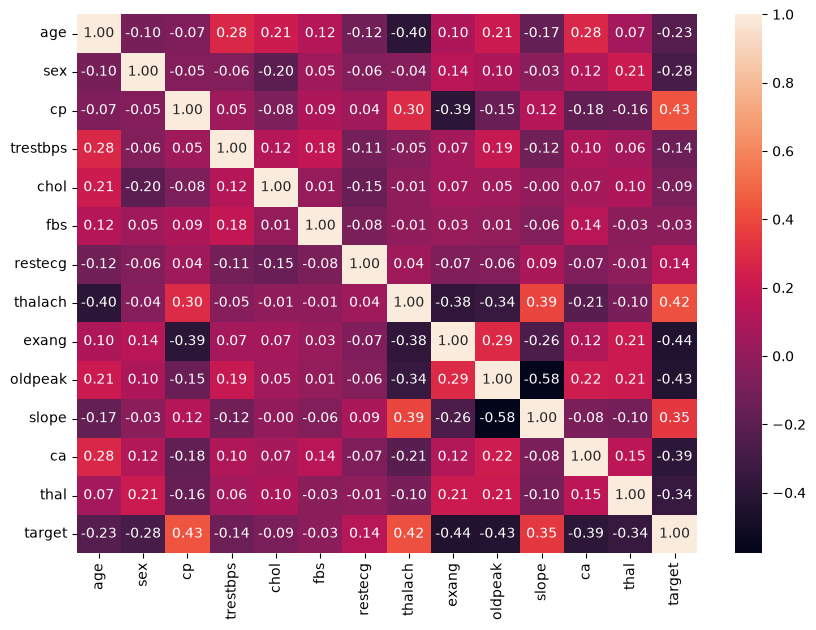

In [298]:
plt.figure(figsize=(10, 7))
ax = sns.heatmap(corrMatrix, annot = True, fmt = ".2f")
plt.show()

In [299]:
X = df.drop("target", axis = 1)
Y = df['target']

print(X)
print("_________________________________")
print(Y)

     age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
0     63    1   3       145   233    1        0      150      0      2.3   
1     37    1   2       130   250    0        1      187      0      3.5   
2     41    0   1       130   204    0        0      172      0      1.4   
3     56    1   1       120   236    0        1      178      0      0.8   
4     57    0   0       120   354    0        1      163      1      0.6   
..   ...  ...  ..       ...   ...  ...      ...      ...    ...      ...   
298   57    0   0       140   241    0        1      123      1      0.2   
299   45    1   3       110   264    0        1      132      0      1.2   
300   68    1   0       144   193    1        1      141      0      3.4   
301   57    1   0       130   131    0        1      115      1      1.2   
302   57    0   1       130   236    0        0      174      0      0.0   

     slope  ca  thal  
0        0   0     1  
1        0   0     2  
2        2   0    

In [315]:
#TRAINING THE MODEL

np.random.seed(42)

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.5)


model1 = RandomForestClassifier()
model1.fit(X_train, Y_train)
model2 = LogisticRegression()
model2.fit(X_train, Y_train)

/opt/anaconda3/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [316]:
#MODEL ACCURACY

print("the accuracy of random Forest: ", model1.score(X_test, Y_test))
print("the accuracy of logestic regression: ", model2.score(X_test, Y_test))

the accuracy of random Forest:  0.8289473684210527
the accuracy of logestic regression:  0.8421052631578947


In [317]:
#WE NEED TO IMPOROVE THE ACCURACY USING HYPERPARAMETER TUNING

#first using RandomizedSearchCV

param_destri = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': [ 'log2'],
    'criterion': ['gini']
    
}

model1_RSCV = RandomizedSearchCV(
        
        estimator=RandomForestClassifier(random_state=42),
        param_distributions=param_destri,
        n_iter=100,
        cv=5,
        scoring='accuracy',       # <-- Must be 'accuracy' or 'f1_weighted', NOT 'r2'
        n_jobs=-1,
        verbose=1,
        random_state=42

)

model1_RSCV.fit(X_train, Y_train)


/opt/anaconda3/lib/python3.14/site-packages/sklearn/model_selection/_search.py:326: UserWarning: The total space of parameters 36 is smaller than n_iter=100. Running 36 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Fitting 5 folds for each of 36 candidates, totalling 180 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'criterion': ['gini'], 'max_depth': [None], 'max_features': ['log2'], 'min_samples_leaf': [1, 2, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",100
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``b

In [318]:
model1_RSCV.score(X_test, Y_test)

0.8157894736842105

In [319]:
print("CV Best Score:", model1_RSCV.best_score_)
print("Best Params:   ", model1_RSCV.best_params_)

CV Best Score: 0.8346236559139785
Best Params:    {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None, 'criterion': 'gini'}


In [320]:
best_rf = model1_RSCV.best_estimator_

print(f"Best CV Accuracy:    {model1_RSCV.best_score_:.4f}")
print(f"Tuned Test Accuracy: {best_rf.score(X_test, Y_test):.4f}")
print("Optimal Parameters: ", model1_RSCV.best_params_)

Best CV Accuracy:    0.8346
Tuned Test Accuracy: 0.8158
Optimal Parameters:  {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None, 'criterion': 'gini'}


In [321]:
#optimising using GridSearchCV

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_destri,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, Y_train)
grid_search.score(X_test, Y_test)

0.8421052631578947

In [322]:
grid_search.best_params_


{'criterion': 'gini',
 'max_depth': None,
 'max_features': 'log2',
 'min_samples_leaf': 2,
 'min_samples_split': 5,
 'n_estimators': 500}

In [323]:
#Removing columns with weak corelation with heart disease

weak_cols = ["fbs", "chol"]

filtered_train = X_train.drop(columns=weak_cols)
filtered_test = X_test.drop(columns=weak_cols)

In [324]:
#training based on the new data set
grid_search.fit(filtered_train, Y_train)
grid_search.score(filtered_test, Y_test)

0.8026315789473685

In [325]:
# One-hot encode the categorical integer columns
nominal_cols = ['cp', 'slope', 'thal', 'ca', 'restecg']
nominal_cols = [c for c in nominal_cols if c in df.columns]

df_encoded = pd.get_dummies(df, columns=nominal_cols, drop_first=True, dtype=int)


X11 = df_encoded.drop(['target', 'fbs','chol'], axis=1)
y11 = df_encoded['target']


# Use a fixed stratified split
X_train_enc, X_test_enc, Y_train_enc, Y_test_enc = train_test_split(
    X11, y11, test_size=0.3, random_state=42, stratify=y
)

In [326]:
grid_search.fit(X_train_enc,Y_train_enc)
grid_search.score(X_test_enc,Y_test_enc)

0.7692307692307693

In [333]:
#Added till this to github

In [336]:
!git log -1 --format="%an <%ae>"

Yash Nimbalkar <nimbalkaryash115@gmail.com>
